# Step 3 — Sentinel-2 vegetation change

Spec: `CLAUDE.md` §6 step 3.

- Pre composite: median NDVI, 1 Feb – 8 Mar 2023, cloud-masked (Cloud Score+ `cs_cdf` > 0.6).
- Post composite: median NDVI, 20 Mar – 30 Apr 2023, cloud-masked.
- Per unit: ΔNDVI = post − pre, plus the number of clear observations in each window, because the
  post window may be cloud-starved.
- **Planned validation (spec §6 step 3):** February 2023 NDVI per field, testing the assumption that
  sequence A fields had a planted crop in March 2023. A planted field should look different in
  February from bare ground. Sequence A units are compared with sequence B/C fields (whose
  strawberries peaked in autumn 2022) and with DWR fields mapped as not cropped (class X).

This is flood *detection* work, not loss measurement: NDVI change is a vegetation signal, and the
exhibit reports it as such.

**CHECKPOINT:** the ΔNDVI map and histogram, and how many units have fewer than 2 clear post
observations. Stop after this.

In [1]:
import ee
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import common as C
import dwr
import optical
from maps import HALO, add_north_arrow, add_scale_bar

ee.Initialize(project=C.EE_PROJECT)

PRE_WINDOW = ("2023-02-01", "2023-03-09")    # 1 Feb - 8 Mar 2023 inclusive
POST_WINDOW = ("2023-03-20", "2023-05-01")   # 20 Mar - 30 Apr 2023 inclusive
FEB_WINDOW = ("2023-02-01", "2023-03-01")    # February only, for the sequence A check
AOI_LL = (-121.90, 36.60, -121.55, 36.98)
N_BARE = 300                                 # DWR "not cropped" fields sampled, seed 0

counties_fc = ee.FeatureCollection(C.COUNTIES).filter(ee.Filter.inList("GEOID", C.COUNTY_GEOIDS))
region = counties_fc.geometry()
counties = gpd.GeoDataFrame.from_features(counties_fc.getInfo()["features"], crs="EPSG:4326")
counties_m = counties[["GEOID", "NAME", "geometry"]].to_crs(C.GRID_CRS)
towns = gpd.GeoDataFrame({"name": list(C.TOWNS)}, crs="EPSG:4326",
                         geometry=gpd.points_from_xy(*zip(*C.TOWNS.values()))).to_crs(C.GRID_CRS)

fields_fc = ee.FeatureCollection(C.UNITS_ASSET)
units_fc = fields_fc.filter(ee.Filter.eq("is_unit", 1))
seqbc_fc = fields_fc.filter(ee.Filter.eq("is_unit", 0))
units_tbl = pd.read_csv(C.DERIVED / "01_units_dwr.csv")
units_tbl["unit_id"] = units_tbl.unit_id.astype(str)
uu = units_tbl[units_tbl.is_unit.astype(bool)]
N_UNITS = len(uu)
DATASETS = f"{C.S2}, {C.S2_CLOUD} (cs_cdf > {C.CLEAR_CS_CDF}), {C.UNITS_ASSET}"


def stamp(window):
    print(f"n units = {N_UNITS} | date window: {window} | datasets: {DATASETS}")


def ndvi_stats(start, end, prefix):
    col = optical.clear_s2(region, start, end)
    ndvi = col.map(lambda im: im.normalizedDifference(["B8", "B4"]).rename("ndvi"))
    return (ndvi.median().rename(prefix + "_ndvi")
            .addBands(ndvi.count().rename(prefix + "_n").unmask(0)))


print(f"n units = {N_UNITS} | pre {PRE_WINDOW[0]} to 2023-03-08 | post {POST_WINDOW[0]} to 2023-04-30")
print(f"datasets: {DATASETS}")

n units = 1320 | pre 2023-02-01 to 2023-03-08 | post 2023-03-20 to 2023-04-30
datasets: COPERNICUS/S2_SR_HARMONIZED, GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED (cs_cdf > 0.6), projects/cropczyk/assets/strawberry_fields_dwr_wy2023


## Per-unit NDVI, change, and clear-observation counts

In [2]:
stack = (ndvi_stats(*PRE_WINDOW, "pre")
         .addBands(ndvi_stats(*POST_WINDOW, "post"))
         .addBands(ndvi_stats(*FEB_WINDOW, "feb")))
BANDS = ["pre_ndvi", "pre_n", "post_ndvi", "post_n", "feb_ndvi", "feb_n"]


def sample(fc, id_prop, ids, extra=(), chunk=200):
    out = []
    for i in range(0, len(ids), chunk):
        part = fc.filter(ee.Filter.inList(id_prop, ids[i:i + chunk]))
        red = stack.reduceRegions(part, ee.Reducer.mean(), scale=10, tileScale=16)
        out += [f["properties"] for f in
                red.select([id_prop] + BANDS + list(extra), retainGeometry=False).getInfo()["features"]]
    df = pd.DataFrame(out)
    df[id_prop] = df[id_prop].astype(str)
    return df


CACHE = C.DERIVED / "03_units_ndvi.csv"
if CACHE.exists():
    units = pd.read_csv(CACHE)
    units["unit_id"] = units.unit_id.astype(str)
    print(f"Loaded cached {CACHE.name} (delete it to recompute)")
else:
    units = sample(units_fc, "unit_id", uu.unit_id.tolist())
    units = units.merge(units_tbl[["unit_id", "COUNTY", "ACRES", "lon", "lat", "sequence"]],
                        on="unit_id", how="left")
    units["d_ndvi"] = units.post_ndvi - units.pre_ndvi
    units.to_csv(CACHE, index=False)
    print(f"Wrote {CACHE.name}")

print(f"units measured: {len(units)} | ΔNDVI median {units.d_ndvi.median():+.3f}, "
      f"10th pct {units.d_ndvi.quantile(0.1):+.3f}, 90th pct {units.d_ndvi.quantile(0.9):+.3f}")
print(f"clear observations per unit: pre median {units.pre_n.median():.0f}, "
      f"post median {units.post_n.median():.0f}")
few = int((units.post_n < 2).sum())
print(f"units with fewer than 2 clear post observations: {few} of {len(units)} "
      f"({100 * few / len(units):.1f}%)")
print(f"units below the spec's image-trigger threshold (ΔNDVI < -0.15 with >= 2 clear post obs): "
      f"{int(((units.d_ndvi < -0.15) & (units.post_n >= 2)).sum())}")
stamp(f"pre {PRE_WINDOW[0]} to 2023-03-08; post {POST_WINDOW[0]} to 2023-04-30")

Loaded cached 03_units_ndvi.csv (delete it to recompute)
units measured: 1320 | ΔNDVI median +0.052, 10th pct -0.049, 90th pct +0.117
clear observations per unit: pre median 3, post median 8
units with fewer than 2 clear post observations: 0 of 1320 (0.0%)
units below the spec's image-trigger threshold (ΔNDVI < -0.15 with >= 2 clear post obs): 12
n units = 1320 | date window: pre 2023-02-01 to 2023-03-08; post 2023-03-20 to 2023-04-30 | datasets: COPERNICUS/S2_SR_HARMONIZED, GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED (cs_cdf > 0.6), projects/cropczyk/assets/strawberry_fields_dwr_wy2023


## Planned validation: did sequence A fields have a crop in February 2023?

Sequence A units against sequence B/C fields and against DWR fields mapped as not cropped (X).
A planted, mulched strawberry field in February carries live vegetation between the beds and on
the beds themselves; bare ground does not.

In [3]:
VAL = C.DERIVED / "03_february_ndvi_check.csv"
if VAL.exists():
    feb = pd.read_csv(VAL)
    feb["group"] = feb.group.astype(str)
    print(f"Loaded cached {VAL.name}")
else:
    all_fields = dwr.load_fields(2023, ["Monterey", "Santa Cruz"])
    cent = all_fields.to_crs("EPSG:4326").centroid
    all_fields = all_fields.assign(lon=cent.x, lat=cent.y)
    in_aoi = (all_fields.lon.between(AOI_LL[0], AOI_LL[2])
              & all_fields.lat.between(AOI_LL[1], AOI_LL[3]))
    def pick(code, label):
        pool = all_fields[in_aoi & all_fields.ACRES.between(2, 100) & (all_fields.MAIN_CROP == code)]
        take = pool.sample(min(N_BARE, len(pool)), random_state=0)
        print(f"DWR '{code}' ({label}) in the valley box: {len(pool)}, sampled {len(take)}")
        ll = take.to_crs("EPSG:4326")
        fc = ee.FeatureCollection([
            ee.Feature(ee.Geometry(g.simplify(0.00002).__geo_interface__, None, False),
                       {"unit_id": str(fid)})
            for g, fid in zip(ll.geometry, ll.UniqueID)])
        return fc, ll.UniqueID.astype(str).tolist()

    bare_fc, bare_ids = pick("X", "not cropped, usually weedy idle ground")
    lett_fc, lett_ids = pick("T30", "lettuce or leafy greens, actively cropped")
    seq_ids = seqbc_fc.aggregate_array("unit_id").getInfo()
    parts = [sample(units_fc, "unit_id", uu.unit_id.tolist()).assign(group="A units"),
             sample(seqbc_fc, "unit_id", seq_ids).assign(group="B/C fields"),
             sample(bare_fc, "unit_id", bare_ids).assign(group="not cropped (X)"),
             sample(lett_fc, "unit_id", lett_ids).assign(group="lettuce (T30)")]
    feb = pd.concat(parts, ignore_index=True)
    feb.to_csv(VAL, index=False)
    print(f"Wrote {VAL.name}")

qs = [0.1, 0.25, 0.5, 0.75, 0.9]
rows = []
for g, d in feb.groupby("group"):
    v = d.feb_ndvi.dropna()
    r = {"group": g, "fields": len(v), "mean": v.mean()}
    r.update({f"p{int(q * 100)}": v.quantile(q) for q in qs})
    r["share below 0.2"] = (v < 0.2).mean()
    rows.append(r)
print("February 2023 NDVI by group:")
print(pd.DataFrame(rows).set_index("group").round(3).to_string())
print()
med = feb.groupby("group").feb_ndvi.median()
print(f"February medians: A units {med['A units']:.3f}, lettuce {med['lettuce (T30)']:.3f}, "
      f"not cropped {med['not cropped (X)']:.3f}, B/C fields {med['B/C fields']:.3f}")
print()
print("READING THIS CHECK")
print("  DWR class X means not cropped for the water year, which in a wet winter is idle ground")
print("  carrying weeds and grass, not bare soil: its February NDVI is the highest of the four")
print("  groups. Mulched strawberry beds are mostly plastic with small plants and read low even")
print("  when fully planted. February NDVI therefore cannot separate a planted strawberry field")
print("  from either idle ground or bare soil, so it cannot confirm or refute the sequence A")
print("  assumption on its own. The seasonal trajectory below is the better test.")
stamp(f"February {FEB_WINDOW[0]} to 2023-02-28")

Loaded cached 03_february_ndvi_check.csv
February 2023 NDVI by group:
                 fields   mean    p10    p25    p50    p75    p90  share below 0.2
group                                                                             
A units            1320  0.280  0.099  0.142  0.245  0.387  0.548            0.424
B/C fields          615  0.314  0.180  0.210  0.268  0.407  0.510            0.210
lettuce (T30)       300  0.243  0.168  0.194  0.219  0.253  0.361            0.313
not cropped (X)     231  0.363  0.148  0.193  0.290  0.519  0.742            0.277

February medians: A units 0.245, lettuce 0.219, not cropped 0.290, B/C fields 0.268

READING THIS CHECK
  DWR class X means not cropped for the water year, which in a wet winter is idle ground
  carrying weeds and grass, not bare soil: its February NDVI is the highest of the four
  groups. Mulched strawberry beds are mostly plastic with small plants and read low even
  when fully planted. February NDVI therefore cannot separate

### Seasonal NDVI trajectory, a better test of the sequence A assumption

A field planted with strawberries in autumn 2022 should green up through the spring harvest and
stay green into the summer. Idle ground greens with the winter rains and browns off in the dry
season. Monthly median NDVI, water year 2023, on a sample of fields per group.

In [4]:
TRAJ = C.DERIVED / "03_ndvi_trajectory.csv"
MONTHS = pd.date_range("2022-10-01", "2023-09-01", freq="MS")
if TRAJ.exists():
    traj = pd.read_csv(TRAJ)
    print(f"Loaded cached {TRAJ.name}")
else:
    sample_n = 200
    ids_by_group = {g: d.unit_id.astype(str).sample(min(sample_n, len(d)), random_state=0).tolist()
                    for g, d in feb.groupby("group")}
    fc_by_group = {"A units": units_fc, "B/C fields": seqbc_fc}
    rows = []
    for m in MONTHS:
        end = (m + pd.offsets.MonthBegin(1)).strftime("%Y-%m-%d")
        col = optical.clear_s2(region, m.strftime("%Y-%m-%d"), end)
        img = (col.map(lambda im: im.normalizedDifference(["B8", "B4"]).rename("ndvi"))
               .median().rename("ndvi"))
        for g, ids in ids_by_group.items():
            fc = fc_by_group.get(g)
            if fc is None:
                continue
            vals = []
            for i in range(0, len(ids), 200):
                part = fc.filter(ee.Filter.inList("unit_id", ids[i:i + 200]))
                red = img.reduceRegions(part, ee.Reducer.mean(), scale=10, tileScale=16)
                vals += [f["properties"].get("mean") for f in
                         red.select(["unit_id", "mean"], retainGeometry=False).getInfo()["features"]]
            vals = [v for v in vals if v is not None]
            rows.append({"month": m.strftime("%Y-%m"), "group": g, "fields": len(vals),
                         "median_ndvi": float(np.median(vals)) if vals else np.nan})
    traj = pd.DataFrame(rows)
    traj.to_csv(TRAJ, index=False)
    print(f"Wrote {TRAJ.name}")

pivot = traj.pivot(index="month", columns="group", values="median_ndvi")
print(pivot.round(3).to_string())
a_traj = pivot.get("A units")
if a_traj is not None:
    peak_month = a_traj.idxmax()
    print()
    print(f"Sequence A units: NDVI rises from {a_traj.iloc[0]:.3f} in October 2022 to a peak of "
          f"{a_traj.max():.3f} in {peak_month}.")
    print("A rise through the spring into a summer peak is what a fall-planted strawberry crop does,")
    print("and it is indirect support for the sequence A assumption. It remains indirect: NDVI cannot")
    print("identify the crop, only that something green grew on the expected schedule.")
stamp("water year 2023, monthly")

Loaded cached 03_ndvi_trajectory.csv
group    A units  B/C fields
month                       
2022-10    0.146       0.679
2022-11    0.146       0.461
2022-12    0.152       0.204
2023-01    0.199       0.241
2023-02    0.222       0.268
2023-03    0.267       0.310
2023-04    0.324       0.307
2023-05    0.443       0.214
2023-06    0.572       0.199
2023-07    0.650       0.197
2023-08    0.689       0.168
2023-09    0.665       0.190

Sequence A units: NDVI rises from 0.146 in October 2022 to a peak of 0.689 in 2023-08.
A rise through the spring into a summer peak is what a fall-planted strawberry crop does,
and it is indirect support for the sequence A assumption. It remains indirect: NDVI cannot
identify the crop, only that something green grew on the expected schedule.
n units = 1320 | date window: water year 2023, monthly | datasets: COPERNICUS/S2_SR_HARMONIZED, GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED (cs_cdf > 0.6), projects/cropczyk/assets/strawberry_fields_dwr_wy2023


## Figure 3 — ΔNDVI map with clear-observation counts

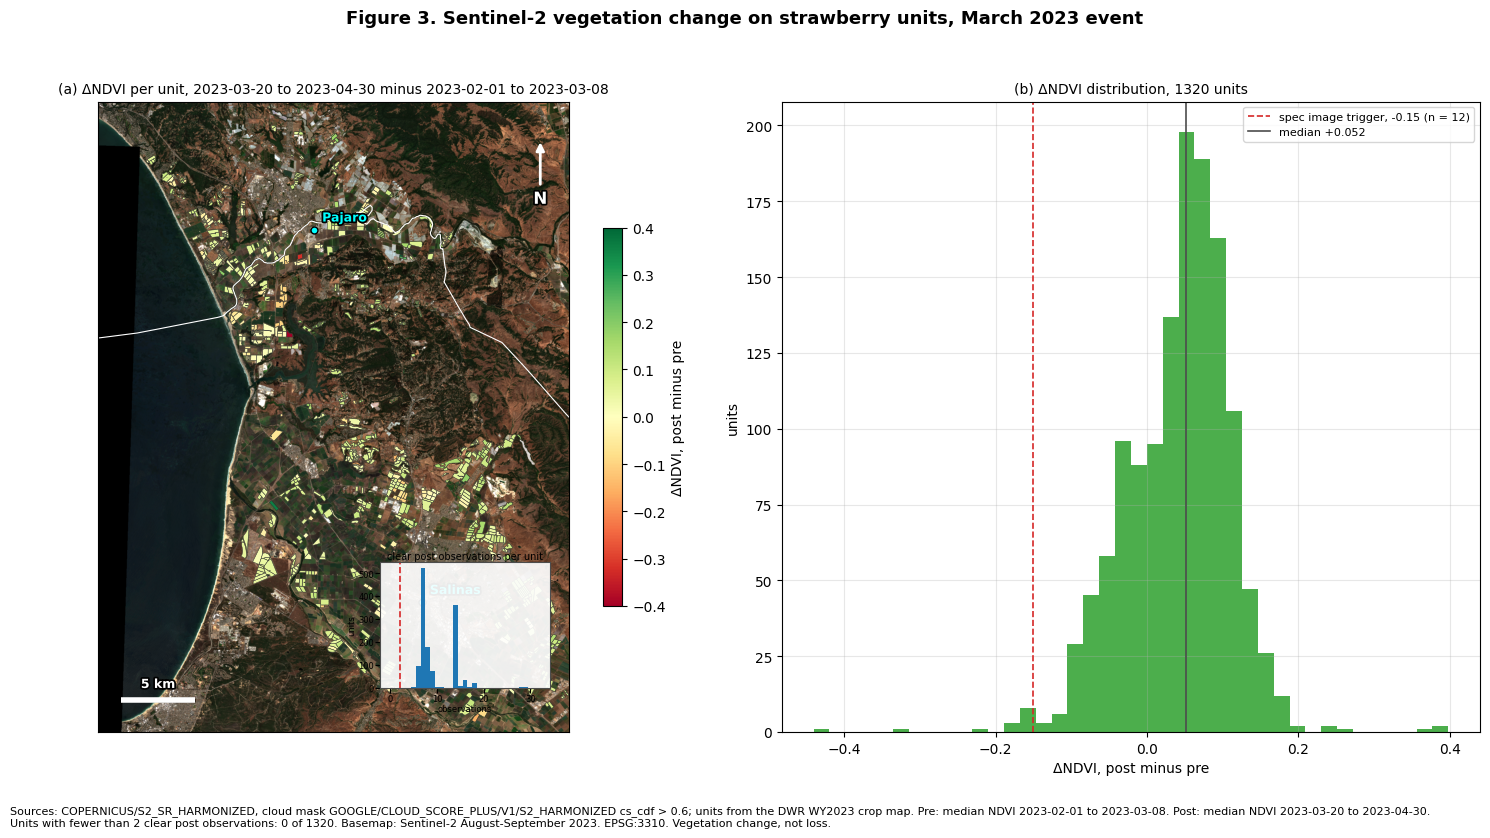

Saved fig3_ndvi_change.png
n units = 1320 | date window: pre 2023-02-01 to 2023-03-08; post 2023-03-20 to 2023-04-30 | datasets: COPERNICUS/S2_SR_HARMONIZED, GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED (cs_cdf > 0.6), projects/cropczyk/assets/strawberry_fields_dwr_wy2023


In [5]:
import rasterio

with rasterio.open(C.DERIVED / "01_basemap_zoom.tif") as src:
    base = np.moveaxis(src.read([1, 2, 3]), 0, -1)
    b = src.bounds
    ext = (b.left, b.right, b.bottom, b.top)

poly = gpd.read_file(C.DERIVED / "01_units_dwr.geojson", engine="fiona").to_crs(C.GRID_CRS)
poly["unit_id"] = poly.unit_id.astype(str)
poly = poly[poly.is_unit.astype(bool)].merge(units[["unit_id", "d_ndvi", "post_n"]], on="unit_id")

fig = plt.figure(figsize=(15, 8.4))
ax = fig.add_subplot(1, 2, 1)
ax.imshow(base, extent=ext, origin="upper")
counties_m.boundary.plot(ax=ax, color="white", lw=0.8)
poly.plot(ax=ax, column="d_ndvi", cmap="RdYlGn", vmin=-0.4, vmax=0.4, legend=True, lw=0.3,
          edgecolor="0.2", legend_kwds={"label": "ΔNDVI, post minus pre", "shrink": 0.6})
for _, t in towns.iterrows():
    ax.plot(t.geometry.x, t.geometry.y, marker="o", ms=5, color="cyan", mec="black")
    ax.annotate(t["name"], (t.geometry.x, t.geometry.y), xytext=(6, 6), textcoords="offset points",
                color="cyan", fontsize=9, fontweight="bold", path_effects=HALO)
ax.set_xlim(ext[0], ext[1])
ax.set_ylim(ext[2], ext[3])
ax.set_xticks([])
ax.set_yticks([])
ax.set_title(f"(a) ΔNDVI per unit, {POST_WINDOW[0]} to 2023-04-30 minus {PRE_WINDOW[0]} to 2023-03-08",
             fontsize=10)
add_scale_bar(ax, 5)
add_north_arrow(ax)

inset = ax.inset_axes([0.60, 0.07, 0.36, 0.20])
inset.hist(units.post_n.dropna(), bins=np.arange(0, units.post_n.max() + 2) - 0.5, color="tab:blue")
inset.axvline(2, color="tab:red", ls="--", lw=1.2)
inset.set_title("clear post observations per unit", fontsize=7, pad=2)
inset.set_xlabel("observations", fontsize=6, labelpad=1)
inset.set_ylabel("units", fontsize=6, labelpad=1)
inset.tick_params(labelsize=6, pad=1)
inset.patch.set_facecolor("white")
inset.patch.set_alpha(0.92)
for sp in inset.spines.values():
    sp.set_edgecolor("0.3")

ax2 = fig.add_subplot(1, 2, 2)
ax2.hist(units.d_ndvi.dropna(), bins=40, color="tab:green", alpha=0.85)
ax2.axvline(-0.15, color="tab:red", ls="--", lw=1.2,
            label=f"spec image trigger, -0.15 (n = {int(((units.d_ndvi < -0.15) & (units.post_n >= 2)).sum())})")
ax2.axvline(units.d_ndvi.median(), color="0.3", lw=1.2,
            label=f"median {units.d_ndvi.median():+.3f}")
ax2.set_xlabel("ΔNDVI, post minus pre")
ax2.set_ylabel("units")
ax2.set_title(f"(b) ΔNDVI distribution, {len(units)} units", fontsize=10)
ax2.grid(alpha=0.3)
ax2.legend(fontsize=8)

fig.suptitle("Figure 3. Sentinel-2 vegetation change on strawberry units, March 2023 event",
             fontsize=13, fontweight="bold")
fig.text(0.01, 0.005,
         f"Sources: {C.S2}, cloud mask {C.S2_CLOUD} cs_cdf > {C.CLEAR_CS_CDF}; units from the DWR "
         f"WY2023 crop map. Pre: median NDVI {PRE_WINDOW[0]} to 2023-03-08. Post: median NDVI "
         f"{POST_WINDOW[0]} to 2023-04-30.\n"
         f"Units with fewer than 2 clear post observations: {int((units.post_n < 2).sum())} of "
         f"{len(units)}. Basemap: Sentinel-2 August-September 2023. EPSG:3310. Vegetation change, "
         f"not loss.",
         fontsize=8, va="bottom")
fig.tight_layout(rect=(0, 0.05, 1, 0.95))
FIG = C.FIGURES / "fig3_ndvi_change.png"
fig.savefig(FIG, dpi=200)
plt.show()
print(f"Saved {FIG.name}")
stamp(f"pre {PRE_WINDOW[0]} to 2023-03-08; post {POST_WINDOW[0]} to 2023-04-30")

## Supplementary figure — seasonal NDVI trajectory

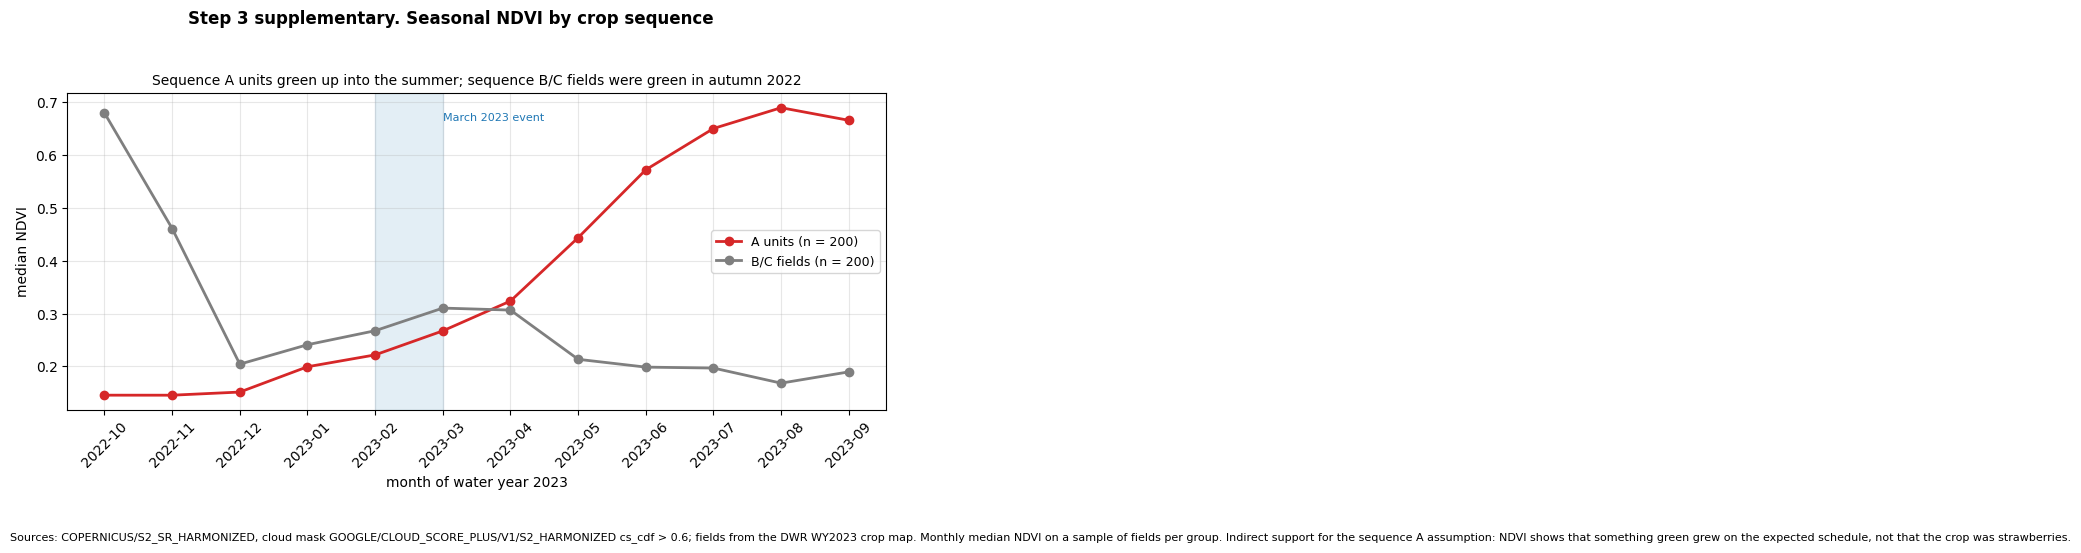

Saved supp_ndvi_trajectory.png
n units = 1320 | date window: water year 2023, monthly | datasets: COPERNICUS/S2_SR_HARMONIZED, GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED (cs_cdf > 0.6), projects/cropczyk/assets/strawberry_fields_dwr_wy2023


In [6]:
fig2, ax3 = plt.subplots(figsize=(9, 5.5))
colors = {"A units": "tab:red", "B/C fields": "tab:gray"}
for g, d in traj.groupby("group"):
    d = d.sort_values("month")
    ax3.plot(d.month, d.median_ndvi, marker="o", lw=2, color=colors.get(g, "tab:blue"),
             label=f"{g} (n = {int(d.fields.median())})")
ax3.axvspan(4.0, 5.0, color="tab:blue", alpha=0.12)
ax3.annotate("March 2023 event", xy=(5.0, ax3.get_ylim()[1] * 0.95), fontsize=8, color="tab:blue",
             ha="left", va="top")
ax3.set_ylabel("median NDVI")
ax3.set_xlabel("month of water year 2023")
ax3.tick_params(axis="x", rotation=45)
ax3.grid(alpha=0.3)
ax3.legend(fontsize=9)
ax3.set_title("Sequence A units green up into the summer; sequence B/C fields were green in autumn 2022",
              fontsize=10)
fig2.suptitle("Step 3 supplementary. Seasonal NDVI by crop sequence", fontsize=12, fontweight="bold")
fig2.text(0.01, 0.01,
          f"Sources: {C.S2}, cloud mask {C.S2_CLOUD} cs_cdf > {C.CLEAR_CS_CDF}; fields from the DWR "
          f"WY2023 crop map. Monthly median NDVI on a sample of fields per group. Indirect "
          f"support for the sequence A assumption: NDVI shows that something green grew on "
          f"the expected schedule, not that the crop was strawberries.",
          fontsize=8, va="bottom")
fig2.tight_layout(rect=(0, 0.08, 1, 0.95))
FIG2 = C.FIGURES / "supp_ndvi_trajectory.png"
fig2.savefig(FIG2, dpi=200)
plt.show()
print(f"Saved {FIG2.name}")
stamp("water year 2023, monthly")